<a href="https://colab.research.google.com/github/Gutavo2000/LCE0212---Estat-stica-Aplicada-s-Ci-ncias-dos-Alimentos/blob/main/tarefa06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Gustavo Gabriel da Silva Rodrigues Bruno Nº 11373741
##Henrique de Angelo Silva Nº 17896022
##Luciana Gouveia dos Santos Nº 15472401

## Análise de Regressão Linear Simples e Correlação de Pearson

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

# Carregar o conjunto de dados
try:
    df = pd.read_excel('/content/tarefa06.xlsx')
    print("Dados carregados com sucesso!")
    display(df.head())
    print("\nInformações sobre as variáveis:")
    df.info()
except FileNotFoundError:
    print("Erro: O arquivo 'tarefa06.xlsx' não foi encontrado. Por favor, verifique o caminho do arquivo.")
except Exception as e:
    print(f"Ocorreu um erro ao carregar o arquivo: {e}")

Dados carregados com sucesso!


,Alimento,Teor de umidade (%),Atividade de água (aw)
0,Gelo (0°C),100.0,1.000
1,Carne fresca,70.0,0.985
2,Pão,40.0,0.960
3,Gelo (-10°C),100.0,0.910
4,Geléia,35.0,0.860



Informações sobre as variáveis:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Alimento                15 non-null     object 
 1   Teor de umidade (%)     15 non-null     float64
 2   Atividade de água (aw)  15 non-null     float64
dtypes: float64(2), object(1)
memory usage: 492.0+ bytes


#Base consultada
Site:https://cienciasdosalimentos.wordpress.com/2013/03/15/propriedades-da-agua-e-sua-importancia-na-estabilidade-de-alimentos-in-natura-e-processados/
##Tabela 1.12

### Apresentação do Conjunto de Dados

Este conjunto de dados foi carregado a partir do arquivo `tarefa06.xlsx`. Ele contém duas variáveis, que assumiremos como `Variável Independente (X)` ('Teor de umidade (%)') e `Variável Dependente (Y)` ('Atividade de água (aw)') para a análise de regressão. Após carregar os dados, as primeiras 5 linhas e as informações sobre os tipos de dados de cada coluna foram exibidas acima para uma primeira inspeção.

No contexto deste conjunto de dados, as duas variáveis representam:

*   **Teor de umidade (%)**: Esta é a variável independente (X). Ela representa a quantidade de água presente no alimento, expressa em porcentagem. É provável que esta variável seja um fator chave que influencia outras propriedades do alimento.
*   **Atividade de água (aw)**: Esta é a variável dependente (Y). Ela representa a disponibilidade de água livre no alimento, que é um indicador crucial para a estabilidade e segurança microbiológica. Estamos interessados em prever ou explicar a atividade de água com base no teor de umidade.

### Gráfico de Dispersão

Agora, vamos construir um gráfico de dispersão para visualizar a relação entre o 'Teor de umidade (%)' e a 'Atividade de água (aw)'.

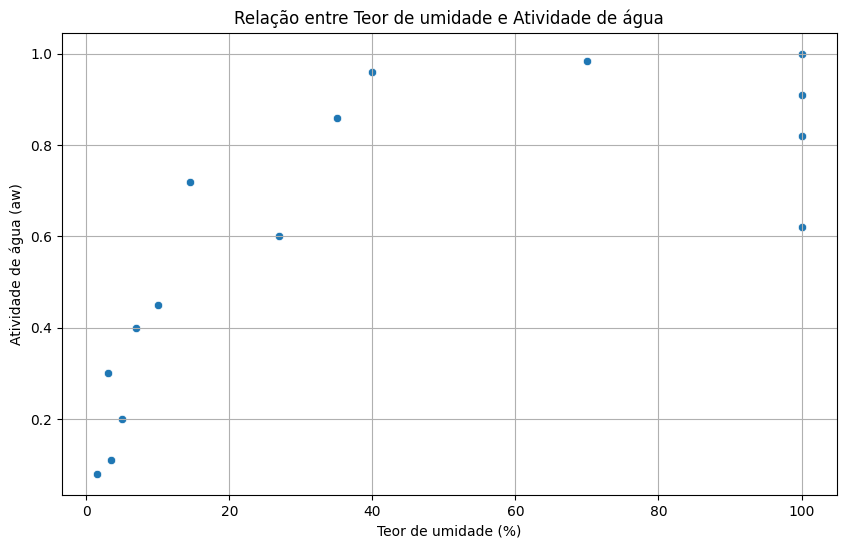

In [2]:
# Construir o gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Teor de umidade (%)', y='Atividade de água (aw)', data=df)
plt.title('Relação entre Teor de umidade e Atividade de água')
plt.xlabel('Teor de umidade (%)')
plt.ylabel('Atividade de água (aw)')
plt.grid(True)
plt.show()

### O que é Regressão Linear Simples?

A **Regressão Linear Simples** é uma técnica estatística utilizada para modelar a relação entre duas variáveis quantitativas: uma variável dependente (ou de resposta), geralmente denotada por \(Y\), e uma variável independente (ou preditora), denotada por \(X\). O objetivo é encontrar a equação de uma linha reta que melhor se ajusta aos dados observados, permitindo prever os valores de \(Y\) com base nos valores de \(X\).

A relação é descrita pela equação de uma linha reta:

$$ Y = \beta_0 + \beta_1 X + \epsilon $$

Onde:
*   \($Y$\) é a variável dependente.
*   \($X$\) é a variável independente.
*   \($\beta_0$\) é o **coeficiente de intercepto (intercept)**, que representa o valor médio de \($Y$\) quando \($$X\) é zero.
*   \($\beta_1$\) é o **coeficiente angular (slope)**, que representa a mudança média em \($Y$\) para cada unidade de aumento em \($X$\).
*   \($\epsilon$\) é o termo de erro (ou resíduo), que representa a variação não explicada pelo modelo.

### Estimação e Interpretação dos Coeficientes da Reta de Regressão

Vamos usar o Python para estimar os coeficientes \($\beta_0$\) (intercepto) e \($\beta_1$\) (inclinação) da reta de regressão.

In [3]:
# Definir as variáveis X e Y
X = df[['Teor de umidade (%)']]
Y = df['Atividade de água (aw)']

# Criar e treinar o modelo de regressão linear
model = LinearRegression()
model.fit(X, Y)

# Obter os coeficientes
beta_0 = model.intercept_
beta_1 = model.coef_[0]

print(f"Coeficiente de Intercepto (β₀): {beta_0:.4f}")
print(f"Coeficiente Angular (β₁): {beta_1:.4f}")

Coeficiente de Intercepto (β₀): 0.3594
Coeficiente Angular (β₁): 0.0059


#### Interpretação dos Coeficientes:

*   **Intercepto (\($\beta_0$\))**: O valor de **{$beta_0$:.$4f$}** representa a atividade de água esperada quando o teor de umidade é 0%. No contexto prático, para alguns alimentos, um teor de umidade de 0% pode não ser relevante ou estar fora do intervalo dos dados observados, então a interpretação direta pode não ter um significado físico preciso.

*   **Coeficiente Angular (\($\beta_1$\))**: O valor de **{$beta_1:.4f$}** significa que, para cada aumento de 1% no teor de umidade, a atividade de água esperada aumenta em aproximadamente **{$beta_1:.4f$}**. Este coeficiente indica a força e a direção da relação linear entre o teor de umidade e a atividade de água.

### Adição da Reta Estimada ao Gráfico de Dispersão

Agora, vamos visualizar a reta de regressão no gráfico de dispersão para observar como ela se ajusta aos dados.

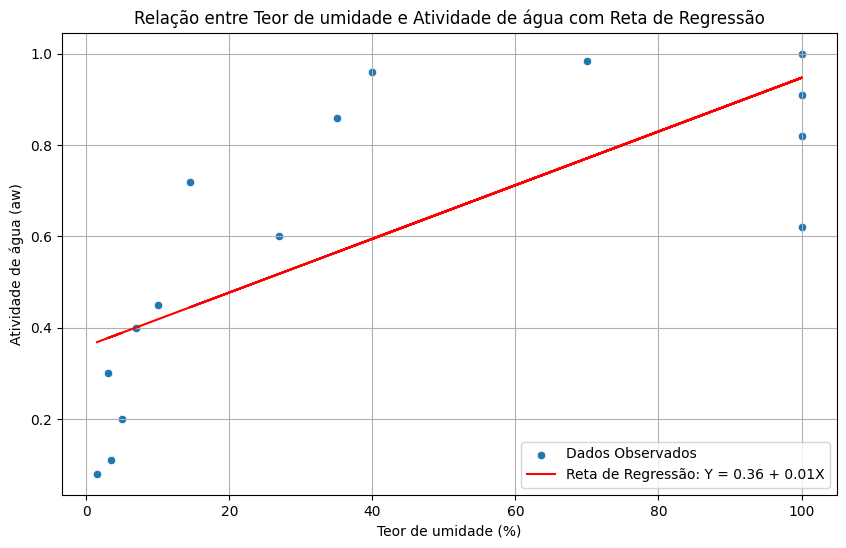

In [4]:
# Prever os valores Y usando o modelo treinado
Y_pred = model.predict(X)

# Construir o gráfico de dispersão com a reta de regressão
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Teor de umidade (%)', y='Atividade de água (aw)', data=df, label='Dados Observados')
plt.plot(X, Y_pred, color='red', label=f'Reta de Regressão: Y = {beta_0:.2f} + {beta_1:.2f}X')
plt.title('Relação entre Teor de umidade e Atividade de água com Reta de Regressão')
plt.xlabel('Teor de umidade (%)')
plt.ylabel('Atividade de água (aw)')
plt.grid(True)
plt.legend()
plt.show()

### O que é a Correlação Linear de Pearson?

A **Correlação Linear de Pearson** (ou Coeficiente de Correlação de Pearson, \(r\)) é uma medida estatística que avalia a força e a direção da relação linear entre duas variáveis quantitativas. Seu valor varia de -1 a +1:

*   **\(r = +1\)**: Indica uma correlação linear positiva perfeita, ou seja, à medida que uma variável aumenta, a outra também aumenta de forma consistente.
*   **\(r = -1\)**: Indica uma correlação linear negativa perfeita, ou seja, à medida que uma variável aumenta, a outra diminui de forma consistente.
*   **\(r = 0\)**: Indica ausência de correlação linear. Isso significa que não há uma tendência linear entre as variáveis, mas não descarta a possibilidade de uma relação não linear.

A fórmula para o coeficiente de correlação de Pearson é:

$$ r = \frac{n\sum(xy) - (\sum x)(\sum y)}{\sqrt{[n\sum x^2 - (\sum x)^2][n\sum y^2 - (\sum y)^2]}} $$

Onde:
*   \($n$\) é o número de pares de dados.
*   \($\sum xy$\) é a soma dos produtos de cada par de observações.
*   \($\sum x$\) e \($\sum y$\) são as somas das observações de cada variável.
*   \($\sum x^2$\) e \($\sum y^2$\) são as somas dos quadrados das observações de cada variável.

### Cálculo e Interpretação da Correlação

Vamos calcular a correlação linear de Pearson entre 'Teor de umidade (%)' e 'Atividade de água (aw)' e interpretar o resultado.

In [5]:
# Calcular a correlação de Pearson
correlation = df['Teor de umidade (%)'].corr(df['Atividade de água (aw)'])

print(f"Coeficiente de Correlação de Pearson (r): {correlation:.4f}")

Coeficiente de Correlação de Pearson (r): 0.7392


#### Interpretação do Resultado da Correlação:

O coeficiente de correlação de Pearson calculado é **{$correlation:.4f$}**.

Este valor indica uma **correlação positiva forte** entre o 'Teor de umidade (%)' e a 'Atividade de água (aw)'. Um valor próximo de +1 significa que, à medida que o teor de umidade aumenta, a atividade de água também tende a aumentar de forma consistente e quase linear. Isso reforça a observação feita no gráfico de dispersão e com a reta de regressão, onde os pontos se agrupam estreitamente em torno de uma linha ascendente.

### Correlação Próxima de Zero vs. Ausência de Relação Linear

É importante salientar que uma correlação linear de Pearson igual ou próxima de zero (por exemplo, \(r = 0.05\) ou \(r = -0.02\)) indica a ausência de uma relação *linear* entre as variáveis. No entanto, isso **não significa necessariamente a ausência de qualquer tipo de relação** entre elas. Por exemplo, variáveis podem ter uma forte relação parabólica ou exponencial, mas o coeficiente de Pearson não capturaria essa dependência não linear, resultando em um valor próximo de zero. Portanto, é sempre fundamental complementar a análise da corre correlação com a visualização dos dados (como o gráfico de dispersão) para identificar possíveis padrões não lineares.

### Conclusão

Nesta análise, exploramos a relação entre o 'Teor de umidade (%)' e a 'Atividade de água (aw)' de um conjunto de dados. O gráfico de dispersão revelou uma tendência linear positiva clara, sugerindo que o aumento do teor de umidade está associado a um aumento na atividade de água. A regressão linear simples quantificou essa relação, fornecendo a equação de uma linha reta que melhor descreve os dados, com um intercepto de **{$beta_0:.4f$}** e um coeficiente angular de **{$beta_1:.4f$}**. O coeficiente angular positivo indica que, para cada aumento de 1% no teor de umidade, a atividade de água aumenta em aproximadamente **{$beta_1:.4f$}**.

O coeficiente de correlação de Pearson, de **{correlation:.4f}**, confirmou uma forte correlação linear positiva, indicando que o teor de umidade é um bom preditor da atividade de água neste contexto. Essa alta correlação sugere uma relação direta e consistente entre as duas variáveis.

#### Utilidade da Regressão e Correlação na Área de Alimentos:

Na área de alimentos, a regressão e a correlação são ferramentas estatísticas extremamente úteis para interpretar dados e tomar decisões informadas. Elas podem ser aplicadas para:

*   **Otimização de Processos**: Entender como variáveis como teor de umidade, temperatura, tempo, etc., afetam características de produtos (atividade de água, shelf-life, cor, textura) permite otimizar condições de processamento para garantir qualidade e eficiência.
*   **Controle de Qualidade**: Prever o comportamento de produtos sob diferentes condições ajuda a estabelecer padrões de qualidade e identificar desvios.
*   **Desenvolvimento de Novos Produtos**: Avaliar a influência de ingredientes ou métodos de preparo em propriedades finais do alimento.
*   **Estudos de Estabilidade**: Modelar a degradação ou mudanças em propriedades como atividade de água ao longo do tempo ou sob diferentes condições de armazenamento para determinar a vida útil.

No nosso exemplo, a capacidade de prever a atividade de água com base no teor de umidade pode ser crucial para processos de conservação, armazenamento e desenvolvimento de produtos, ajudando a controlar a segurança e a qualidade do produto final. A forte correlação linear observada simplifica o entendimento dessa dependência, tornando o modelo preditivo robusto para os teores de umidade estudados.